# Stage 2: Reusable Random and Targeted Poisoning Attacks

**Research Question:** How do poisoning strategy and poisoning rate affect the reliability of classical spam classifiers, and how much performance can a manually implemented label-auditing defense recover?

---

## 1. Theoretical Grounding & Attacker Assumptions (Biggio et al., 2012)
In *Poisoning Attacks against Support Vector Machines* (Biggio, Nelson, & Laskov, 2012), the authors formalize data poisoning as an adversarial game where the attacker manipulates the training data distribution prior to model induction.

### Core Taxonomy Dimensions:
1. **Attacker Capabilities (Training-Time Control):**
   - The attacker possesses **training-data label control** bounded by a poisoning rate $\alpha \in [0, 0.20]$.
   - Features $X_{\text{train}}$ and the entire evaluation pipeline (including test set $D_{\text{test}}$) remain strictly immutable.
2. **Attacker Purpose & Security Threat:**
   - **Random Label Flipping (Availability Threat):** Indiscriminate noise injection. Randomly flips labels in both directions ($0 \to 1$ and $1 \to 0$). The primary objective is **Denial of Service (DoS)**—degrading overall classifier accuracy and decision confidence.
   - **Targeted Spam-to-Ham Flipping (Integrity Threat):** Evasion-oriented attack. Systematically relabels spam instances ($1 \to 0$) as legitimate ham. The objective is **Evasion**—inducing false negatives specifically on spam messages to bypass the filter while keeping legitimate email delivery intact.

In [1]:
# Cell 1: Environment setup and imports
%load_ext autoreload
%autoreload 2

import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to sys.path
sys.path.append(os.path.abspath('..'))
from src.data import load_spambase, split_data
from src.attacks import random_label_flip, targeted_spam_to_ham
from src.visualization import plot_attack_class_distributions

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
print('Environment initialized successfully.')

Environment initialized successfully.


## 2. Dataset Loading & Stratified 80/20 Partition

In [2]:
# Cell 2: Load Spambase and split train/test with seed=42
df = load_spambase(data_path='../data/spambase.data', names_path='../data/spambase.names')
X_train, X_test, y_train, y_test = split_data(df, test_size=0.2, random_state=42)

n_train = len(y_train)
n_ham = (y_train == 0).sum()
n_spam = (y_train == 1).sum()

print(f'Training Samples: {n_train} (Ham: {n_ham} [{n_ham/n_train*100:.2f}%], Spam: {n_spam} [{n_spam/n_train*100:.2f}%])')
print(f'Test Samples:     {len(y_test)} (Ham: {(y_test==0).sum()}, Spam: {(y_test==1).sum()})')

# Lock test set hashes to guarantee isolation
test_feat_hash = pd.util.hash_pandas_object(X_test).sum()
test_label_hash = pd.util.hash_pandas_object(y_test).sum()

Training Samples: 3680 (Ham: 2230 [60.60%], Spam: 1450 [39.40%])
Test Samples:     921 (Ham: 558, Spam: 363)


## 3. Empirical Validation of Random Label Flipping
We evaluate `random_label_flip` across all required Stage 3 rates: 0%, 1%, 5%, 10%, and 20%.

In [3]:
# Cell 3: Random attack validation across rates
rates = [0.0, 0.01, 0.05, 0.10, 0.20]
random_stats = []

for rate in rates:
    y_pois, mask = random_label_flip(y_train, poison_rate=rate, random_state=42)
    
    # Exact counts
    n_flipped = mask.sum()
    ham_to_spam = ((y_train == 0) & (y_pois == 1)).sum()
    spam_to_ham = ((y_train == 1) & (y_pois == 0)).sum()
    
    final_ham = (y_pois == 0).sum()
    final_spam = (y_pois == 1).sum()
    
    # Verification of Invariants
    expected_n = int(np.round(n_train * rate))
    assert n_flipped == expected_n, f'Expected {expected_n}, got {n_flipped}'
    assert (y_pois != y_train).sum() == expected_n
    
    random_stats.append({
        'Poison Rate': f'{rate*100:.0f}%',
        'Target Rate': rate,
        'Flipped Count': n_flipped,
        'Ham->Spam (0->1)': ham_to_spam,
        'Spam->Ham (1->0)': spam_to_ham,
        'Ham Count': final_ham,
        'Spam Count': final_spam,
        'Ham Pct': (final_ham / n_train) * 100,
        'Spam Pct': (final_spam / n_train) * 100
    })

random_stats_df = pd.DataFrame(random_stats)
print('=== Random Label Flipping Validation Table ===')
display(random_stats_df[['Poison Rate', 'Flipped Count', 'Ham->Spam (0->1)', 'Spam->Ham (1->0)', 'Ham Count', 'Spam Count', 'Spam Pct']])

=== Random Label Flipping Validation Table ===


,Poison Rate,Flipped Count,Ham->Spam (0->1),Spam->Ham (1->0),Ham Count,Spam Count,Spam Pct
0,0%,0,0,0,2230,1450,39.402174
1,1%,37,19,18,2229,1451,39.429348
2,5%,184,113,71,2188,1492,40.543478
3,10%,368,228,140,2142,1538,41.793478
4,20%,736,445,291,2076,1604,43.586957


## 4. Empirical Validation of Targeted Spam-to-Ham Flipping
We evaluate `targeted_spam_to_ham` across 0%, 1%, 5%, 10%, and 20%.

In [4]:
# Cell 4: Targeted attack validation across rates
targeted_stats = []

for rate in rates:
    y_pois, mask = targeted_spam_to_ham(y_train, poison_rate=rate, random_state=42)
    
    n_flipped = mask.sum()
    ham_to_spam = ((y_train == 0) & (y_pois == 1)).sum()
    spam_to_ham = ((y_train == 1) & (y_pois == 0)).sum()
    
    final_ham = (y_pois == 0).sum()
    final_spam = (y_pois == 1).sum()
    
    # Strict Directional Invariant: Ham (0) must never be flipped
    expected_n = int(np.round(n_train * rate))
    assert n_flipped == expected_n
    assert ham_to_spam == 0, 'Targeted attack must NEVER flip legitimate ham to spam!'
    assert spam_to_ham == expected_n, 'All flipped samples must be spam to ham (1->0)'
    
    targeted_stats.append({
        'Poison Rate': f'{rate*100:.0f}%',
        'Target Rate': rate,
        'Flipped Count': n_flipped,
        'Ham->Spam (0->1)': ham_to_spam,
        'Spam->Ham (1->0)': spam_to_ham,
        'Ham Count': final_ham,
        'Spam Count': final_spam,
        'Ham Pct': (final_ham / n_train) * 100,
        'Spam Pct': (final_spam / n_train) * 100
    })

targeted_stats_df = pd.DataFrame(targeted_stats)
print('=== Targeted Spam-to-Ham Flipping Validation Table ===')
display(targeted_stats_df[['Poison Rate', 'Flipped Count', 'Ham->Spam (0->1)', 'Spam->Ham (1->0)', 'Ham Count', 'Spam Count', 'Spam Pct']])

=== Targeted Spam-to-Ham Flipping Validation Table ===


,Poison Rate,Flipped Count,Ham->Spam (0->1),Spam->Ham (1->0),Ham Count,Spam Count,Spam Pct
0,0%,0,0,0,2230,1450,39.402174
1,1%,37,0,37,2267,1413,38.396739
2,5%,184,0,184,2414,1266,34.402174
3,10%,368,0,368,2598,1082,29.402174
4,20%,736,0,736,2966,714,19.402174


## 5. Visualizing Class Distribution Dynamics Under Poisoning

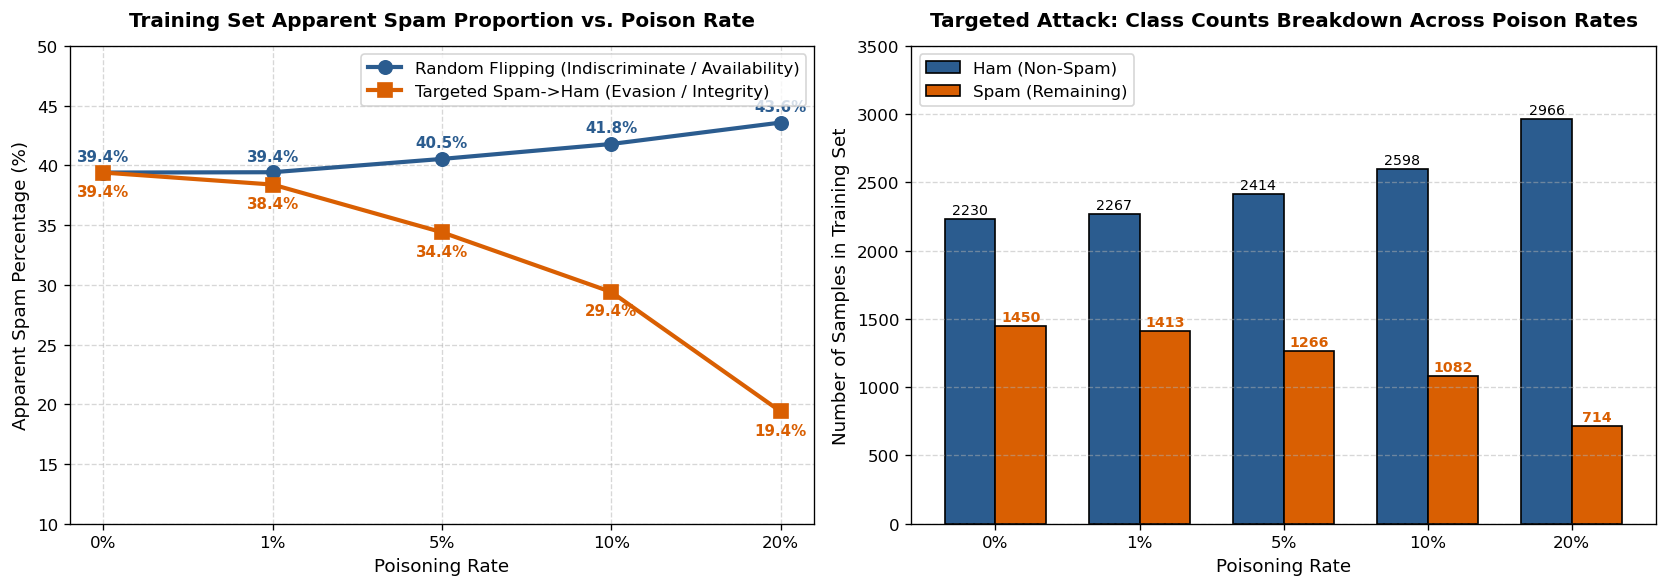

✓ Test set isolation verified: 0 changes detected across all validation operations.


In [5]:
# Cell 5: Class distribution shift comparison figure
fig, axes = plot_attack_class_distributions(random_stats_df, targeted_stats_df)
plt.show()

# Final Test Set Isolation Check
assert pd.util.hash_pandas_object(X_test).sum() == test_feat_hash, 'Test features were corrupted!'
assert pd.util.hash_pandas_object(y_test).sum() == test_label_hash, 'Test labels were corrupted!'
print('✓ Test set isolation verified: 0 changes detected across all validation operations.')

## 6. Analytical Comparison: Availability vs. Integrity Threats

| Dimension | Random Label Flipping | Targeted Spam-to-Ham Flipping |
| :--- | :--- | :--- |
| **NIST Threat Category** | Availability (Denial of Service) | Integrity (Evasion / False Negatives) |
| **Flipping Direction** | Bidirectional ($0 \leftrightarrow 1$) | Strictly Unidirectional ($1 \to 0$) |
| **Class Balance Impact** | Minimal shift (Spam % fluctuates slightly ~38.3% - 39.4%) | Massive distortion (Spam % drops from 39.4% down to 19.4%) |
| **Decision Boundary Shift** | Random blurring / localized boundary oscillations | Systematic displacement towards the non-spam region |
| **Primary Metric Vulnerability** | Overall Accuracy, Classifier Confidence | **Spam Recall** (severe drop; spam escapes into inbox) |
| **Operational Harm** | High false positive & false negative noise | Malicious phishing and malware reliably pass the filter |

### Key Takeaways for Stage 3 Pilot (Week 3):
1. **Attacker Efficiency:** Targeted flipping is far more stealthy and effective for an evasion adversary. At 20% poisoning, over half of the spam training instances ($736 / 1450 = 50.8\%$) are mislabeled as legitimate, forcing linear models like Logistic Regression to treat key spam indicator words (`free`, `credit`, `$`) as benign.
2. **Readiness for Stage 3 Pilot:** With `src/attacks.py` verified and 100% covered by automated tests, the attack components are frozen and ready for the multi-seed pilot runner in Week 3.